# UT4. Práctica 2: Diagnóstico y Color
**Alumno/a:** Javier Peralta

En la sesión anterior aprendimos a acceder a los píxeles (Anatomía). Hoy vamos a aprender a **diagnosticar** la salud de una imagen y a **repararla** matemáticamente.

### Objetivos:
1.  **El Histograma:** Leer la gráfica de luz de una imagen.
2.  **Reparación:** Corregir fotos oscuras o lavadas (Brillo y Contraste).
3.  **Seguridad:** Entender por qué `np.clip` salva vidas.
4.  **Espacios de Color:** Convertir de RGB a HSV para ver cómo ven los robots.

Imagen cargada: (768, 1408, 3) - Tipo: uint8


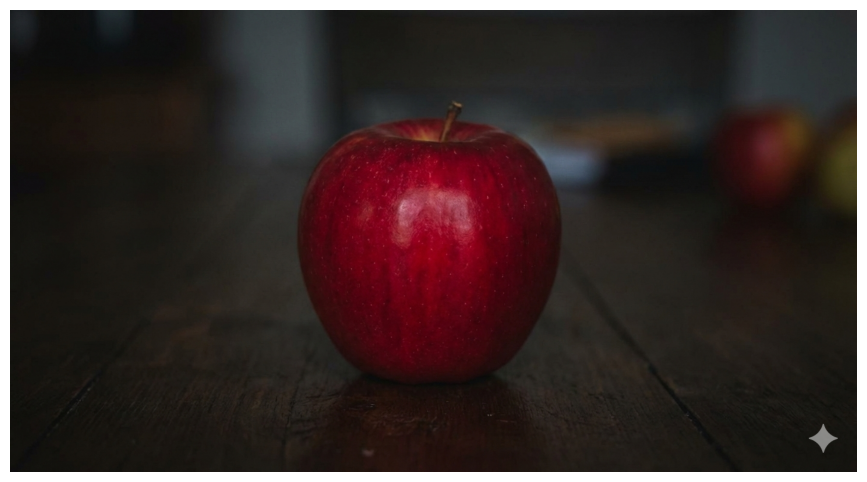

In [132]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors # Necesario para el cambio a HSV

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 6]

# CARGA DE IMAGEN
# Carga una imagen cualquiera que tengas (asegúrate de que tenga color)
try:
    imagen = plt.imread('images/imagen_a_analizar.png')  # Cambia esto por tu archivo
except:
    # Si falla, genera una imagen de prueba
    print("No se encontró imagen. Usando patrón de prueba.")
    X, Y = np.meshgrid(np.linspace(0, 1, 400), np.linspace(0, 1, 400))
    imagen = np.stack((X, Y, np.zeros_like(X)), axis=2)
    imagen = (imagen * 255).astype('uint8')

# NOTA DE SEGURIDAD: Si la imagen es PNG y viene en float (0-1), la pasamos a uint8 (0-255)
if imagen.dtype == np.float32 or imagen.dtype == np.float64:
    imagen = (imagen * 255).astype('uint8')

# Vamos a quitarle el canal Alpha si lo tiene (RGBA -> RGB)
if imagen.shape[2] == 4:
    imagen = imagen[:,:,:3]

print(f"Imagen cargada: {imagen.shape} - Tipo: {imagen.dtype}")
plt.imshow(imagen)
plt.axis('off')
plt.show()

---

## 1. El Histograma: El Electrocardiograma de la Foto
Antes de tocar nada, necesitamos diagnosticar.
Vamos a simular que tu cámara ha fallado y ha sacado una foto **Subexpuesta (Oscura)** y de **Bajo Contraste**.

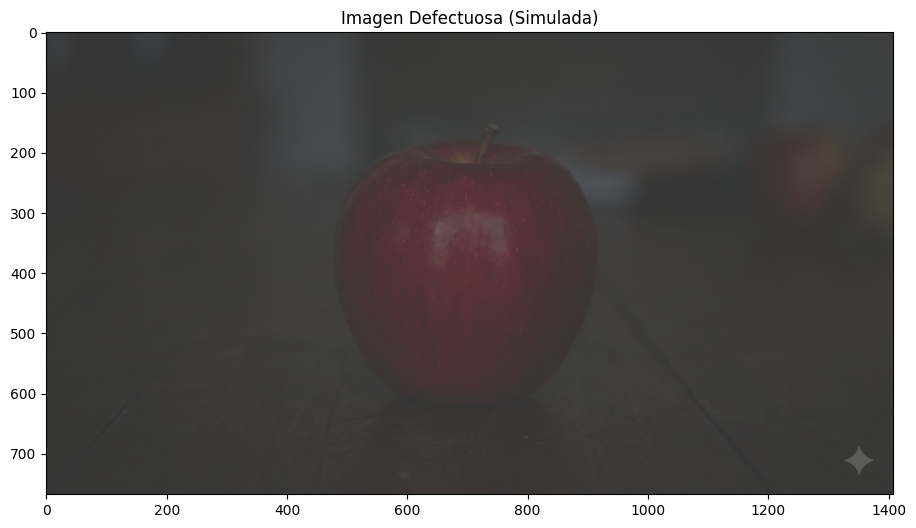

In [133]:
# SIMULACIÓN DE ERROR (No toques esto, solo ejecútalo)
# Creamos una versión "rota" de tu foto: Oscura y grisácea
imagen_mala = (imagen * 0.3 + 50).astype('uint8')

plt.imshow(imagen_mala)
plt.title("Imagen Defectuosa (Simulada)")
plt.show()

**Misión:** Genera el histograma de la `imagen_mala`.
* Recuerda: `plt.hist` necesita una lista plana de números, no una matriz 3D. Usa `.ravel()`.
* Configura 256 `bins` (contenedores).

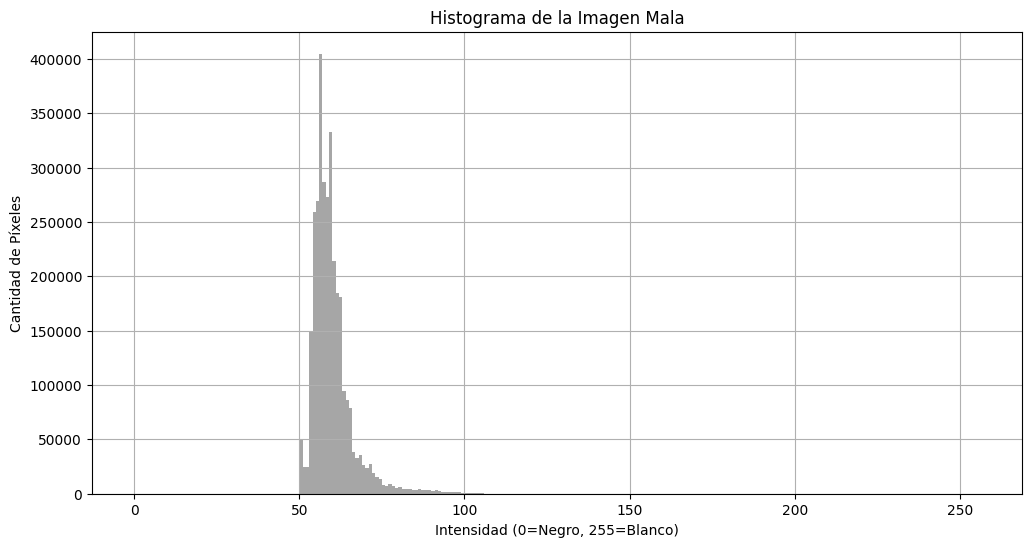

In [134]:
plt.hist(imagen_mala.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)

plt.title("Histograma de la Imagen Mala")
plt.xlabel("Intensidad (0=Negro, 255=Blanco)")
plt.ylabel("Cantidad de Píxeles")
plt.grid(True)
plt.show()

> **Pregunta de examen:** Mira la gráfica que acabas de generar.
> 1. ¿Dónde está la "montaña" de datos? (¿Izquierda, Centro, Derecha?)
> 2. ¿Ocupa todo el ancho del gráfico (0-255) o está estrecha?
> 3. Según las diapositivas 19 y 20, ¿qué dos problemas tiene esta imagen?
>
> *Respuesta:*
1. Todos los datos están a la izquierda
2. Está estrecha (de 50 a 100 más o menos)
3. La imagen está subexpuesta y con bajo contraste.

---

## 2. Reparación Matemática (Operaciones Puntuales)
Vamos a arreglar la `imagen_mala` usando matemáticas.

### Teoría (Diapositivas 21 y 22)
* **Brillo (Suma):** Desplaza la montaña a la derecha.
* **Contraste (Multiplicación):** Ensancha la montaña.
* **Clamping (Seguridad):** Evita el *Overflow* (nieve negra).

**Misión:** Aumentar el contraste por 2 y subir el brillo 20 puntos.

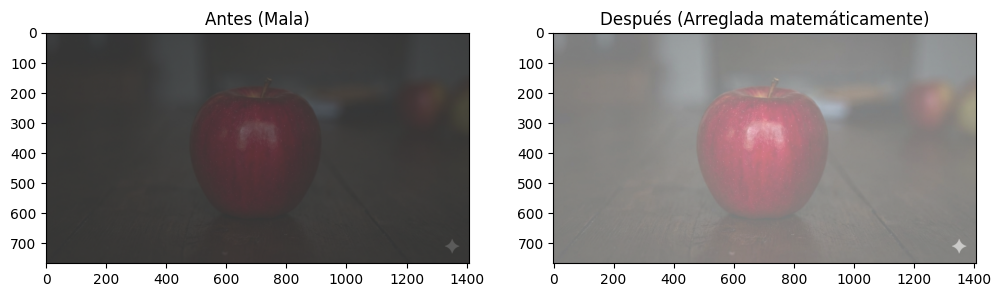

In [135]:
# PASO 1: Conversión de seguridad
# Pasamos a float para que 250 + 50 no de "4" (Overflow)
img_float = imagen_mala.astype('float32')

# PASO 2: Operaciones Matemáticas
# Fórmula: Nuevo = (Viejo * Contraste) + Brillo
# Aplica: Multiplicar por 2.0 y luego sumar 20
img_arreglada_temp = (img_float * 2) + 20

# PASO 3: Clamping (Pinzamiento)
# Importante: Obligar a que los valores estén entre 0 y 255
img_arreglada_clip = np.clip(img_arreglada_temp, 0, 255)

# PASO 4: Vuelta a uint8
imagen_final = img_arreglada_clip.astype('uint8')

# VISUALIZACIÓN COMPARATIVA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(imagen_mala)
ax1.set_title("Antes (Mala)")

ax2.imshow(imagen_final)
ax2.set_title("Después (Arreglada matemáticamente)")
plt.show()

---

## 3. Espacios de Color: Visión Humana vs Robótica (HSV)
Las imágenes llegan en **RGB** (Hardware), pero para analizar colores usamos **HSV** (Lógica).
Vamos a ver cómo "ve" el ordenador la **Saturación** (pureza del color).

**Misión:** Convertir la imagen original a HSV y mostrar solo el Canal S.

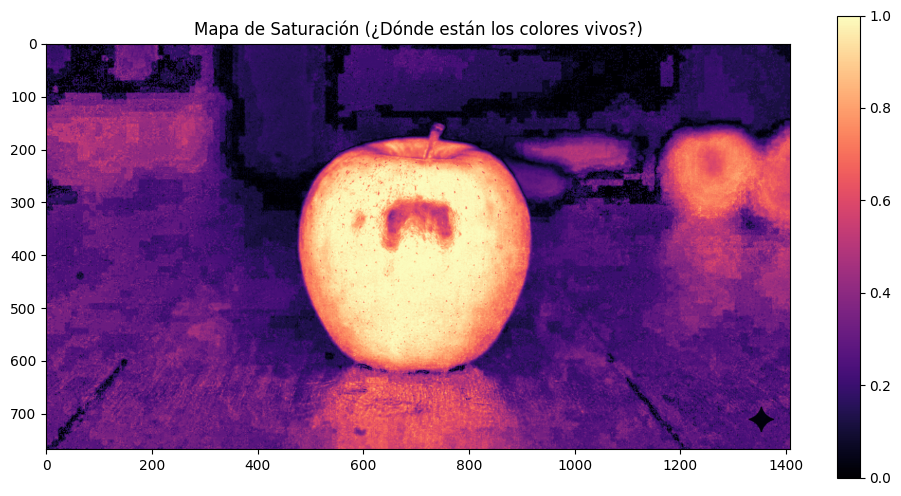

In [136]:
# 1. Convertir de RGB a HSV
# IMPORTANTE: Normalizamos manualmente a float (0-1) para evitar errores de versión
imagen_float = imagen.astype('float32') / 255.0

# La función está en la librería 'colors' que importamos arriba
# PISTA: Debes pasarle 'imagen_float' (la normalizada), no 'imagen'
imagen_hsv = colors.rgb_to_hsv(imagen_float)

# 2. Extraer el canal de Saturación
# En HSV: Canal 0=Hue, Canal 1=Saturation, Canal 2=Value
canal_saturacion = imagen_hsv[:, :, 1]

# 3. Visualizar con mapa de calor
plt.imshow(canal_saturacion, cmap='magma')
plt.title("Mapa de Saturación (¿Dónde están los colores vivos?)")
plt.colorbar() # Muestra la barra de referencia
plt.show()

> **Observa:** En la imagen de arriba, las zonas blancas/amarillas son las que tienen colores muy vivos en la foto original. Las zonas negras/moradas eran grises o blancas en la foto original. **¡Acabas de separar el "color" de la "luz"!**

---

## RETO FINAL: El Detector de Objetos

Imagina que queremos detectar **solo los píxeles rojos** de tu imagen.
En el espacio HSV, el color Rojo está al principio del ciclo (Valores de Hue cercanos a 0.0) O al final (cercanos a 1.0).

Escribe un código que:
1. Extraiga el **Canal Hue** (Matiz) de `imagen_hsv`.
2. Cree una **máscara** (True/False) seleccionando los píxeles que tengan un Hue menor a 0.05 (Rojos).
3. Muestre esa máscara con `plt.imshow` (cmap='gray').

*Pista: Es solo hacer Slicing y una comparación mayor/menor (<).* 

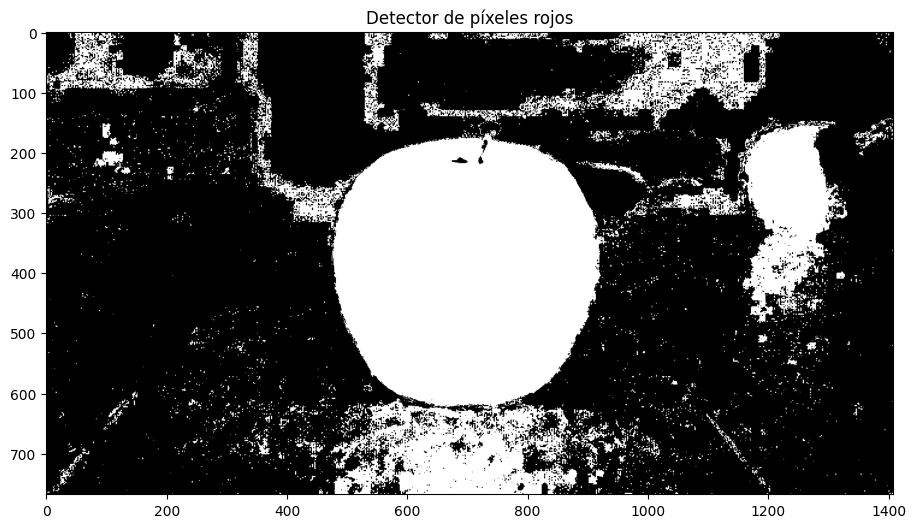

In [137]:
hue = imagen_hsv[:, :, 0]
mascara_roja = (hue < 0.05) | (hue > 0.95)
plt.imshow(mascara_roja, cmap="gray")
plt.title("Detector de píxeles rojos")
plt.show()

---

# Retos Extra
Si has llegado hasta aquí y te sobra tiempo, intenta resolver estos problemas avanzados que ponen a prueba todo lo aprendido.

### Reto Extra 1: El Ojo Humano (Grayscale Manual)
Muchas librerías convierten a Blanco y Negro automáticamente, pero... ¿sabes cómo lo hacen?
No es una media simple `(R+G+B)/3`. El ojo humano es muy sensible al Verde, medio al Rojo y poco al Azul.

**La Fórmula de la Luminancia:**
$$Gris = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$$

**Misión:** Crea una imagen en escala de grises manualmente aplicando esta fórmula a los canales de tu imagen original.
*Pista: Separa los canales R, G y B en variables distintas, multiplícalos y súmalos.*

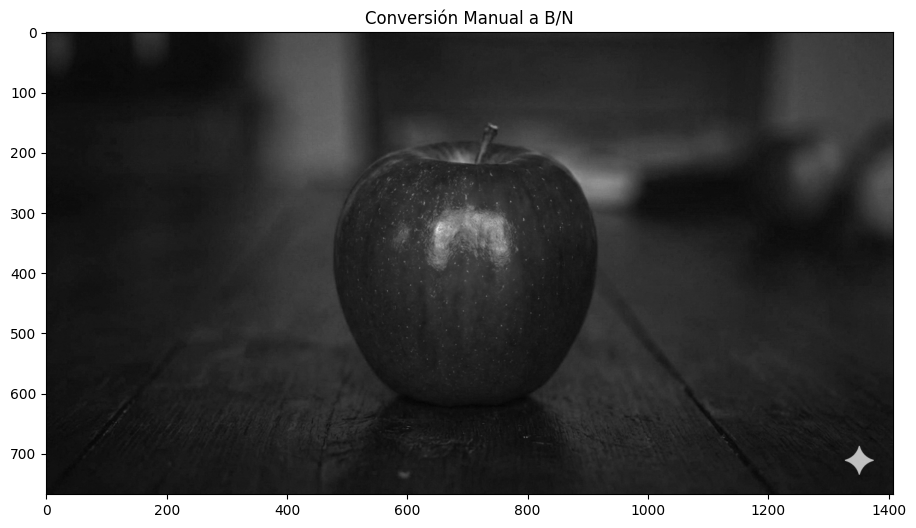

In [138]:
# 1. Separa los canales (Slicing)
R = imagen[:,:,0]
G = imagen[:,:,1]
B = imagen[:,:,2]

# 2. Aplica la fórmula (Recuerda: al operar se convierten a float, luego vuelve a uint8)
gris_manual = (0.299 * R + 0.587 * G + 0.114 * B).astype('uint8')

# 3. Visualiza (Ojo: plt.imshow necesita cmap='gray' si la imagen es 2D)
plt.imshow(gris_manual, cmap='gray')
plt.title("Conversión Manual a B/N")
plt.show()

### Reto Extra 2: El "Auto-Corrector" (Normalización)
En el ejercicio 2 ajustaste el brillo y contraste "a ojo" (multiplicando por 2).
¿Y si quisiéramos un algoritmo que arregle **cualquier** foto automáticamente para que aproveche todo el rango (0-255)?

**La Fórmula de Normalización Min-Max:**
$$Pixel_{new} = \frac{Pixel - min}{max - min} \cdot 255$$

**Misión:** Aplica esta fórmula a la `imagen_mala`.
1. Encuentra el valor mínimo (`.min()`) y máximo (`.max()`) de la imagen mala.
2. Aplica la fórmula.
3. Convierte a `uint8` y visualiza.

Rango actual: 50 a 119. Objetivo: 0 a 255


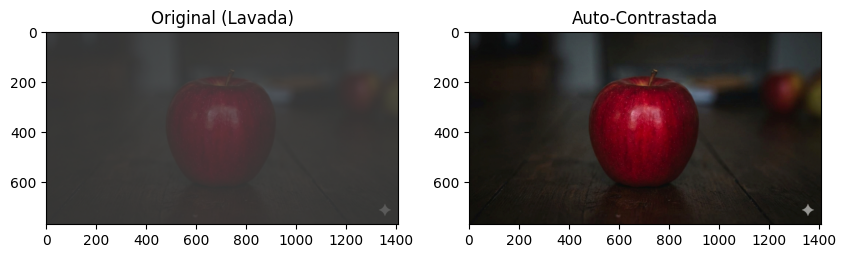

In [139]:
min_val = imagen_mala.min()
max_val = imagen_mala.max()

print(f"Rango actual: {min_val} a {max_val}. Objetivo: 0 a 255")

# Aplica la fórmula (Cuidado con los paréntesis)
imagen_auto = (imagen_mala - min_val) / (max_val - min_val) * 255
imagen_auto = imagen_auto.astype("uint8")

# Comprobación visual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
ax1.imshow(imagen_mala); ax1.set_title("Original (Lavada)")
ax2.imshow(imagen_auto); ax2.set_title("Auto-Contrastada")
plt.show()

### Reto Extra 3: La Camiseta Mágica (Modificar HSV)
Ya sabes detectar píxeles rojos (Reto Final). Ahora... ¡vamos a cambiarlos de color!

**Lógica:**
1. Trabajamos sobre una copia HSV (`imagen_hsv.copy()`).
2. Usamos la máscara del reto anterior (`mascara_roja`) para seleccionar solo esos píxeles.
3. Les asignamos un nuevo valor de Hue (por ejemplo, 0.6 para azul).
4. Convertimos de vuelta a RGB para ver el resultado.

**Misión:** Convierte los objetos rojos de tu foto en azules (o verdes).

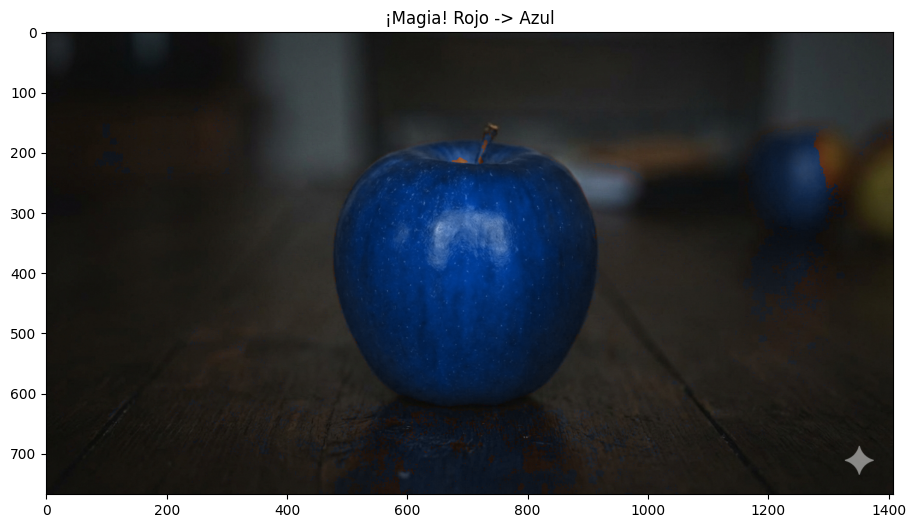

In [141]:
# 1. Hacemos una copia para no romper nada
img_hsv_mod = imagen_hsv.copy()

# 2. Modificamos el canal HUE (Canal 0)
# Accedemos SOLO a los píxeles donde la máscara es True y al canal 0
# Sintaxis: imagen[mascara, canal] = nuevo_valor
img_hsv_mod[mascara_roja, 0] = 0.6  # 0.6 es Azul aprox, 0.3 es Verde

# 3. Volvemos a RGB para visualizar
imagen_cambiada = colors.hsv_to_rgb(img_hsv_mod)

plt.imshow(imagen_cambiada)
plt.title("¡Magia! Rojo -> Azul")
plt.show()